# Increasing Marketing ROI with Customer Segmentation

## Executive Summary

This project addresses a key business challenge for a bike retailer: how to move from generic mass marketing to a targeted, data-driven strategy. By analyzing transactional data, we have successfully segmented the entire customer base into four distinct, actionable groups.

Our most critical finding is the identification of two key segments: the **"Champions,"** a small group of highly valuable and loyal customers, and the **"At-Risk Champions,"** a group of previously high-value customers who are in danger of churning.

This report outlines a clear framework for understanding who these customers are and provides a set of specific, targeted marketing recommendations for each group. The implementation of these strategies has the potential to significantly increase customer retention, drive revenue growth, and maximize marketing return on investment (ROI).


## Phase 1: Methodology & Data Preparation



### 1.1 Our Mission and Objectives:
The mission of this project is to transform raw transactional data into a strategic asset. We will achieve this by segmenting the entire customer base into distinct, actionable groups based on their purchasing behavior.

Our specific objectives are:
+ To engineer a robust dataset by cleaning and structuring transactional sales data in a relational database.
+ To quantify customer value by implementing the RFM (Recency, Frequency, Monetary) model.
+ To apply the **K-Means clustering algorithm**, a powerful unsupervised learning technique, to identify natural groupings within the customer data.
+ To rigorously validate the chosen number of segments using both visual (Elbow Method) and quantitative (Silhouette Score) techniques.
+ To develop detailed "personas" for each customer segment and deliver a set of **specific, data-driven marketing recommendations** tailored to each group.

Ultimately, this project will provide the bike retailer with a clear, actionable framework to personalize their marketing, enhance customer loyalty, and drive measurable revenue growth.

### 1.2 Data Preparation:
The first and most critical step is to build a reliable data foundation. We transformed the raw CSV files into a robust relational database and engineered the key features needed for our analysis.

**Our process included:**
* **Setting up a MySQL Database:** To ensure data integrity and simulate a real-world production environment.
* **Data Cleaning & Loading:** We identified and removed duplicate records from the product data to ensure accuracy before loading all data into the database.
* **Feature Engineering (RFM Model):** We used SQL to calculate the Recency, Frequency, and Monetary (RFM) value for each customer. These three metrics form the analytical backbone of our segmentation model.

In [ ]:
!pip install sqlalchemy

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [ ]:
db_user = 'root'
db_password_plain = 'Password'
db_host = 'localhost'
db_name = 'bike_sales'

In [ ]:
db_password_encoded = quote_plus(db_password_plain)

In [ ]:
connection_str = f'mysql+mysqlconnector://{db_user}:{db_password_encoded}@{db_host}/{db_name}'
engine = create_engine(connection_str)

In [ ]:
rfm_query = """
WITH RFM_Base AS (
    SELECT
        c.customer_id,
        c.first_name,
        c.last_name,
        DATEDIFF('2019-01-01', MAX(o.order_date)) AS recency,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(oi.quantity * oi.list_price * (1 - oi.discount)) AS monetary
    FROM
        customers c
    JOIN
        orders o ON c.customer_id = o.customer_id
    JOIN
        order_items oi ON o.order_id = oi.order_id
    GROUP BY
        c.customer_id, c.first_name, c.last_name
)
SELECT * FROM RFM_Base;
"""

In [ ]:
rfm_df = pd.read_sql(rfm_query, engine)

In [ ]:
print("Successfully loaded RFM data:")
print(rfm_df.head())

Successfully loaded RFM data:
   customer_id  first_name last_name  recency  frequency    monetary
0            1       Debra     Burks       44          3  27888.1834
1            2       Kasha      Todd      267          3  19329.0849
2            3      Tameka    Fisher       72          3  24051.5279
3            4       Daryl    Spence      258          3  21150.8927
4            5  Charolette      Rice      259          3  17520.2919


In [ ]:
rfm_features = rfm_df[['recency', 'frequency', 'monetary']]

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

---
## Phase 2: How We Determined the Right Number of Segments

A key decision in customer segmentation is choosing the right number of groups. A model that is too simple (e.g., 2 groups) provides little insight, while a model that is too complex (e.g., 10 groups) is not actionable. To make a robust, data-driven choice, we used a two-step validation process.


### 2.1 The Elbow Method:
We first used this visual heuristic to find the "point of diminishing returns"—the point where adding another cluster doesn't provide a significant benefit. This gave us a strong initial hypothesis that **k=4** was the most efficient number of clusters.

In [ ]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

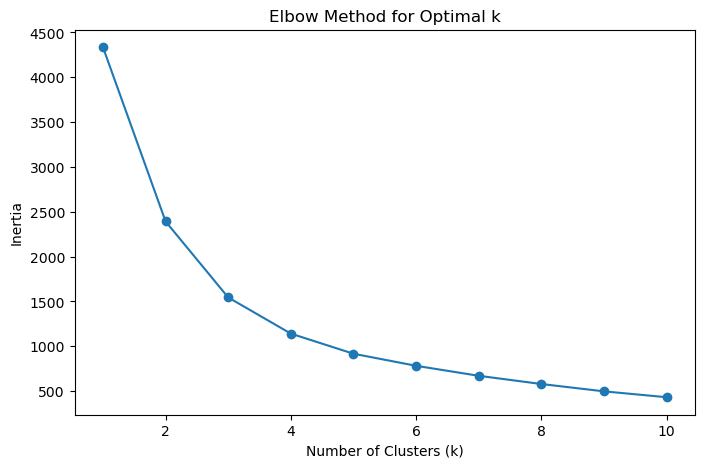

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### 2.2 The Silhouette Score: 
To validate our hypothesis quantitatively, we calculated the average Silhouette Score. This score measures how well-separated and distinct the clusters are. Our analysis showed a strong local peak at **k=4**, providing statistical evidence that this is the optimal number of segments.


In [ ]:
silhouette_scores = []
for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

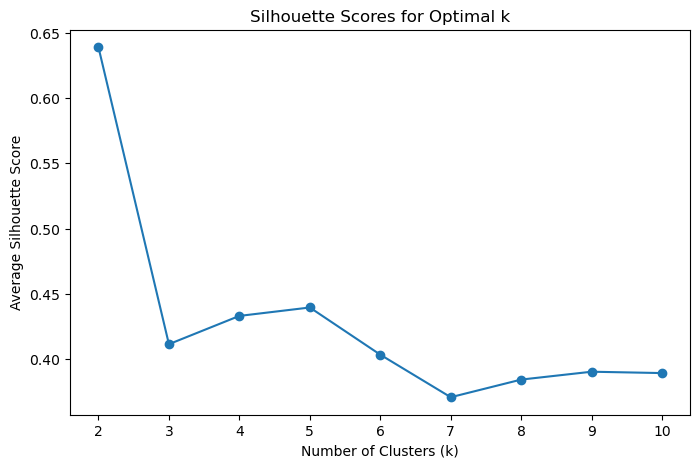

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.show()

**Justification:** In the Silhouette score plot, we see that the curve has a higher peak at **k=5** compared to the one at **k=4**, but still, we will choose the latter option over the other. It is mainly because, the tiny statistical improvement gained by moving to five clusters comes at the cost of a more complex and less actionable model. The four segments are clear, distinct, and each maps to a unique business strategy. Adding a fifth segment will likely create a small, confusing "splinter" group without a clear strategic purpose, violating the principle of model simplicity.

Thus, by combining these two methods, we can be highly confident that our choice of four customer segments is not arbitrary but is the most valid and meaningful representation of the underlying data.

---
## Phase 3: The Four Customer Segments - A High-Level View

With the optimal number of clusters determined, we built our final model. The analysis revealed four distinct customer segments. The pie chart below provides an immediate overview of the customer base, highlighting that our most valuable group, the **"Champions,"** constitutes a relatively small portion of the total, making them a critical segment to protect and nurture.

**Technical Note:** *The final K-Means model was run with k=4. The resulting cluster labels were then mapped to descriptive names to facilitate analysis. We then used a series of visualizations to explore the results.*

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['cluster'] = kmeans.fit_predict(rfm_scaled)

C:\Users\Subhayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [ ]:
segment_map = {
    0: 'Lost Customers',
    1: 'Champions',
    2: 'New & Promising',
    3: 'At-Risk Champions'
}

In [ ]:
rfm_df['segment'] = rfm_df['cluster'].map(segment_map)

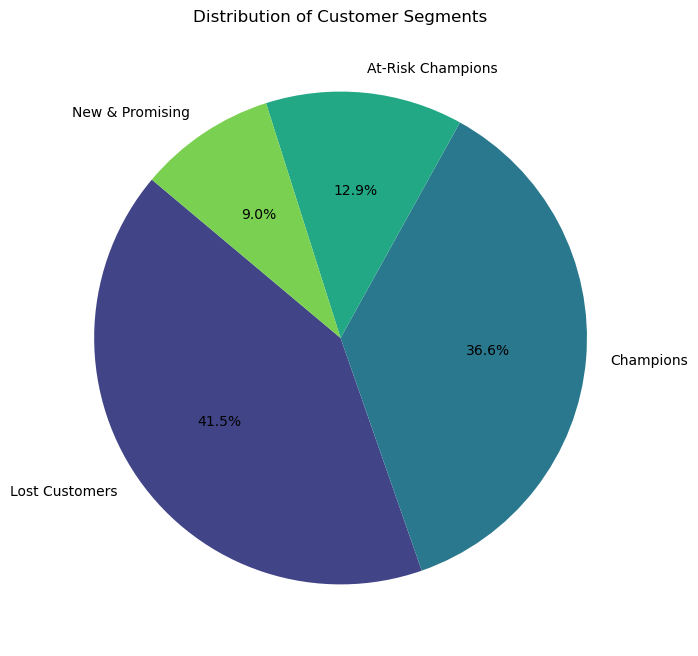

In [ ]:
segment_counts = rfm_df['segment'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('viridis', len(segment_counts)))
plt.title('Distribution of Customer Segments')
plt.ylabel('') 
plt.show()

### 3.1 Visualizing the Cluster Separation

To confirm that our model created truly distinct groups, we visualized the segments. The scatter plots below—including an advanced **t-SNE plot** which represents the three RFM dimensions in a 2D space—clearly show that the four segments are well-separated. This gives us strong confidence in the validity of our final customer personas.

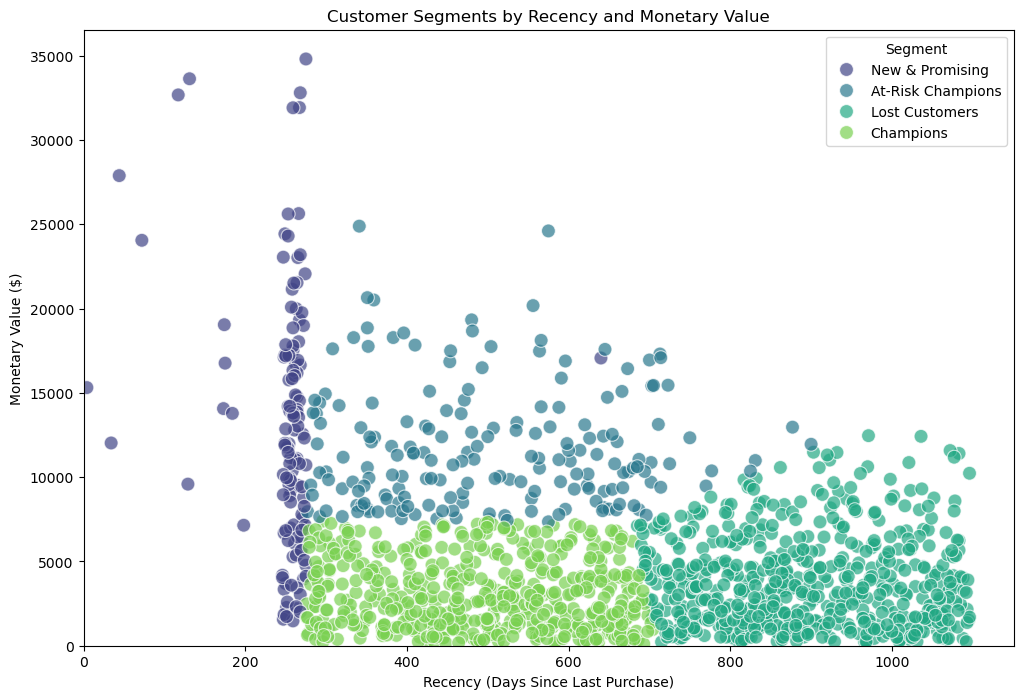

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=rfm_df, x='recency', y='monetary', hue='segment',
                palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments by Recency and Monetary Value')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Segment')
plt.ylim(0)
plt.xlim(0)
plt.show()

In [ ]:
tsne = TSNE(n_components=2, verbose=0, perplexity=40, max_iter=300, random_state=42)
tsne_results = tsne.fit_transform(rfm_scaled)
rfm_df['tsne-2d-one'] = tsne_results[:,0]
rfm_df['tsne-2d-two'] = tsne_results[:,1]

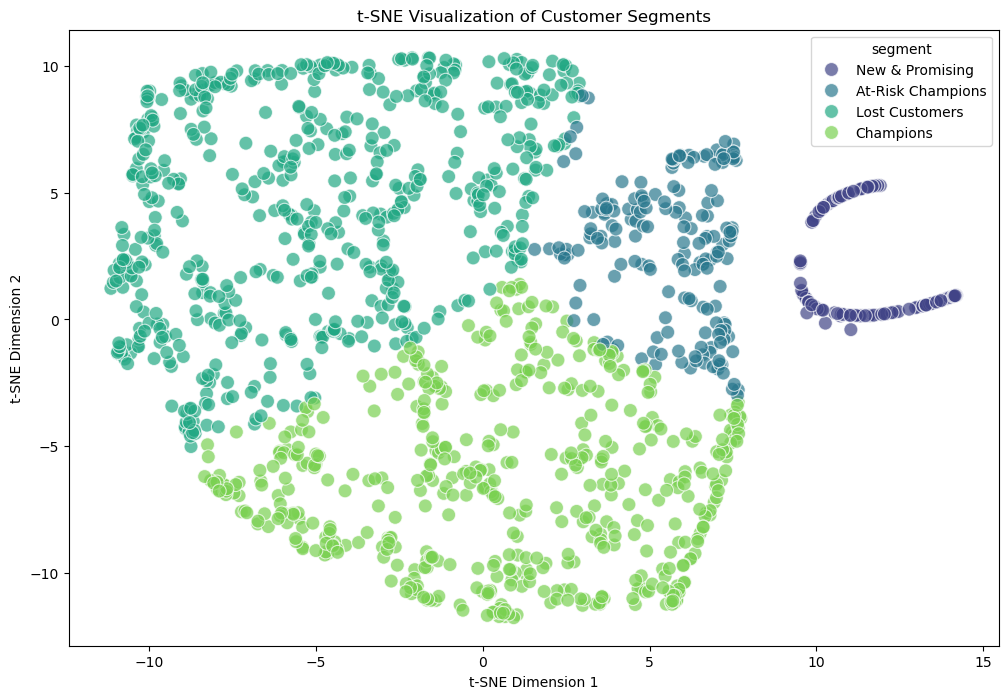

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="segment",
    palette=sns.color_palette("viridis", 4),
    data=rfm_df,
    legend="full",
    s=100,
    alpha=0.7
)
plt.title('t-SNE Visualization of Customer Segments')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

---
## Phase 4: Unveiling the Customer Personas

This is where we translate the data into business insight. By analyzing the average RFM characteristics of each group, we can build clear "personas" that a marketing team can easily understand and target. The **Bar charts** below provide a clear, side-by-side comparison of the spending and purchasing frequency for each group.

In [ ]:
print(rfm_df.groupby('segment')[['recency', 'frequency', 'monetary']].mean())

                      recency  frequency      monetary
segment                                               
At-Risk Champions  503.636364   1.000000  11723.947796
Champions          495.512287   1.000000   2989.338275
Lost Customers     893.903172   1.001669   3714.516217
New & Promising    250.207692   2.300000  13002.947372


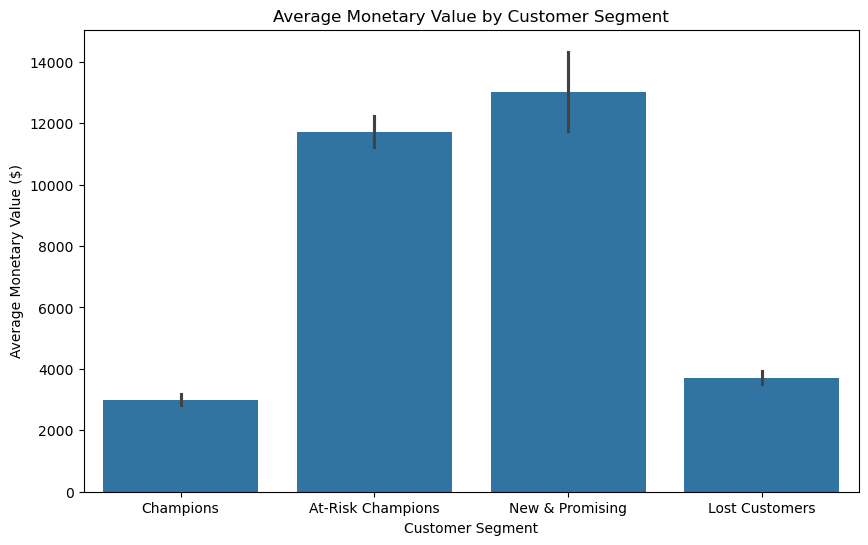

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='monetary', data=rfm_df, order=['Champions', 'At-Risk Champions', 'New & Promising', 'Lost Customers'])
plt.title('Average Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value ($)')
plt.show()

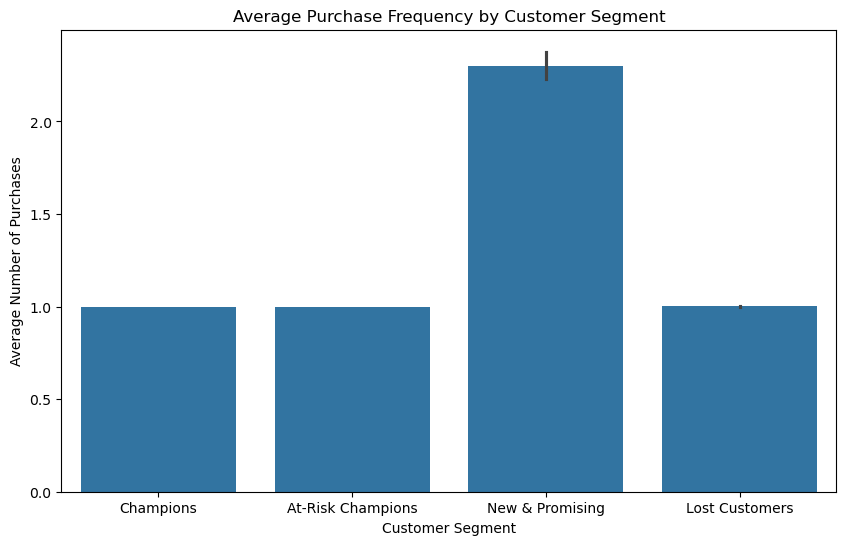

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='frequency', data=rfm_df, order=['Champions', 'At-Risk Champions', 'New & Promising', 'Lost Customers'])
plt.title('Average Purchase Frequency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Number of Purchases')
plt.show()

Following the bar charts, the **Radar Chart** below provides the most powerful visual "fingerprint" of these personas, instantly showing what makes each group unique.

In [ ]:
print(rfm_df.head())

   customer_id  first_name last_name  recency  frequency    monetary  cluster  \
0            1       Debra     Burks       44          3  27888.1834        2   
1            2       Kasha      Todd      267          3  19329.0849        2   
2            3      Tameka    Fisher       72          3  24051.5279        2   
3            4       Daryl    Spence      258          3  21150.8927        2   
4            5  Charolette      Rice      259          3  17520.2919        2   

           segment  tsne-2d-one  tsne-2d-two  
0  New & Promising     9.974236     4.084914  
1  New & Promising    10.481799     4.678489  
2  New & Promising    10.121133     4.323009  
3  New & Promising    10.341340     4.553118  
4  New & Promising    10.624400     4.791089  


In [ ]:
radar_data = rfm_df.groupby('segment')[['recency', 'frequency', 'monetary']].mean().reset_index()

In [ ]:
radar_data['recency'] = radar_data['recency'].max() - radar_data['recency']

In [ ]:
scaler = MinMaxScaler()
radar_data_scaled = pd.DataFrame(scaler.fit_transform(radar_data[['recency', 'frequency', 'monetary']]),
                                 columns=['recency', 'frequency', 'monetary'])
radar_data_scaled['segment'] = radar_data['segment']

In [ ]:
labels = np.array(['High Recency*', 'High Frequency', 'High Monetary'])
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

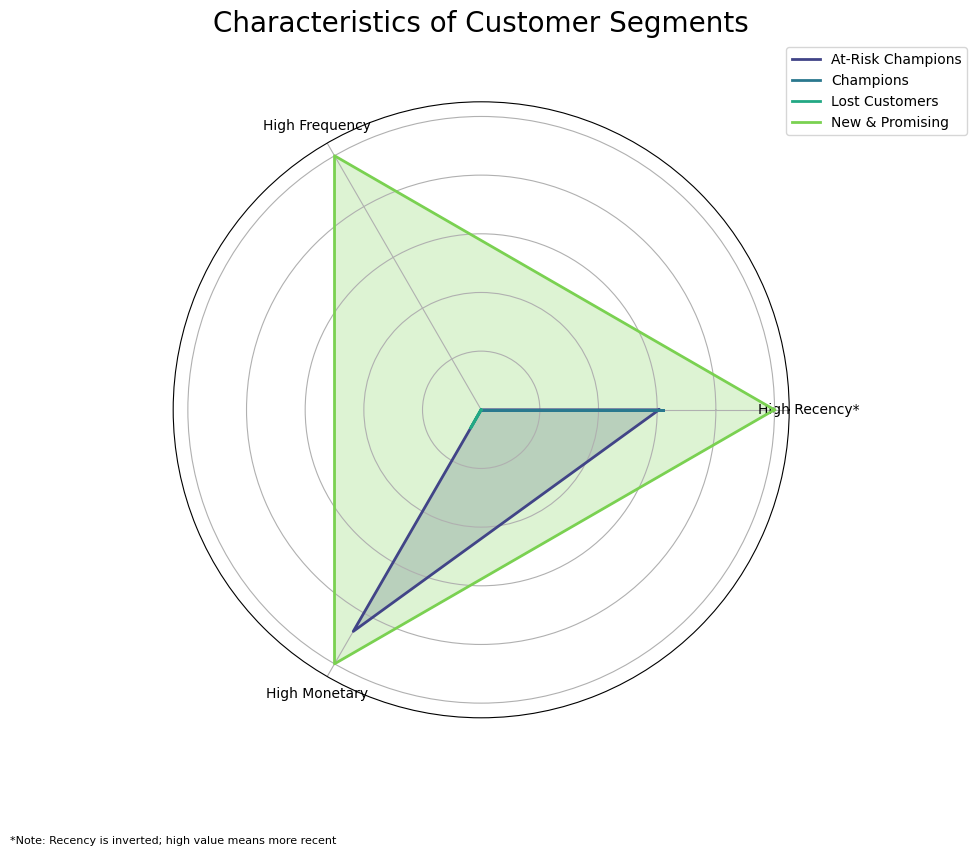

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette('viridis', 4)

for index, row in radar_data_scaled.iterrows():
    segment_name = row['segment']
    values = row[['recency', 'frequency', 'monetary']].values.flatten().tolist()
    values += values[:1]  # Complete the loop
    ax.plot(angles, values, color=colors[index], linewidth=2, label=segment_name)
    ax.fill(angles, values, color=colors[index], alpha=0.25)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Characteristics of Customer Segments', size=20, y=1.1)
ax.text(x=0, y=-0.2, s='*Note: Recency is inverted; high value means more recent',
        ha='center', va='center', fontsize=8, color='black', transform=ax.transAxes)
plt.show()

Based on the charts we just saw, we now focus on the proper identification of the "personas" we created.

### Our Four Customer Personas:

* **Champions 🏆:** These are our best and most loyal customers. They have purchased very recently, buy frequently, and spend the most. They are the bedrock of the business and our primary focus for retention.

* **At-Risk Champions 😥:** These were once high-value customers who spent a lot and bought often, but they have not made a purchase in a long time. They are our highest-priority group for immediate re-engagement efforts.

* **New & Promising 🌱:** These are new customers who have purchased recently but have not yet spent much or become loyal. They represent the biggest growth opportunity and should be nurtured to become future Champions.

* **Lost Customers 👋:** These are low-value, inactive customers. They require minimal marketing investment, as resources are better spent on the other, more valuable segments.

---
## Phase 5: Strategic Recommendations - An Action Plan for Growth

Based on our analysis, we recommend a tailored marketing strategy for each customer segment. This approach will allow the business to allocate its resources more effectively, focusing its efforts where they will have the greatest impact.

### Recommended Actions:

**1. For Champions:**
* **Action:** Launch a "Pro Rider" loyalty program in Q4 2025. Offer exclusive early access to new products and a 15% discount on accessories.
* **Goal:** Increase the average purchase frequency of this segment by 10% within 12 months.

**2. For At-Risk Champions:**
* **Action:** Immediately launch a personalized "We Miss You" re-engagement campaign via email and social media. Offer a compelling, limited-time discount on their previously purchased product categories.
* **Goal:** Win back at least 20% of this segment (i.e., get them to make a purchase) within the next quarter.

**3. For New & Promising Customers:**
* **Action:** Create an automated "Welcome" email series that onboards them to the brand, provides value (e.g., bike maintenance tips), and offers a small incentive for their second purchase.
* **Goal:** Increase the conversion rate from first-time to second-time purchase by 15%.

**4. For Lost Customers:**
* **Action:** Dedicate minimal marketing resources to this segment. Keep them in a low-effort, automated email newsletter to maintain brand awareness at a low cost.
* **Goal:** Focus budget and effort on the other, more valuable segments.